# Demonstration of SIVE model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import glob
import os
os.chdir("src")

import evaluation as eval
import utils

### Load SIVE test set
Download here: https://zenodo.org/records/17122999

In [2]:
# Update paths as needed
seen_location_path = "../data/SIVE/test_1/"
points_dict_path = "../data/SIVE/points_dict.npy"

points_dict = np.load(points_dict_path, allow_pickle=True).item()

In [3]:
# Load seen location test set
target_pos = -1

test_paths = glob.glob(seen_location_path + '*.npy')
test_targets = [np.load(file)[target_pos] for file in test_paths]
test_input = [np.load(file)[0:target_pos] for file in test_paths]

print("Test dimensions:")
print("Number of samples:", len(test_input))
print("Shape of target:", np.shape(test_targets[0]))
print("Shape of input:", np.shape(test_input[0]))

Test dimensions:
Number of samples: 9
Shape of target: (750, 650)
Shape of input: (5, 750, 650)


## Load model
Model is served using torch hub: https://github.com/conorosully/vegetation-line-models

<br>
Currently, only the best SimpleCNN model from the paper is provided.

In [4]:
# Load simpleCNN model trained on SIVE dataset
model, meta_data = torch.hub.load("conorosully/vegetation-line-models", 
                                    "get_model",
                                    state_dict='SIVE_SimpleCNN.pth',
                                    guidance=True,
                                    force_reload=True)
print(meta_data)

Downloading: "https://github.com/conorosully/vegetation-line-models/zipball/main" to /Users/conorosullivan/.cache/torch/hub/main.zip
{'name': 'SIVE_SimpleCNN', 'date': '04/JUNE/2024', 'arcitecture': 'HED', 'backbone': 'SimpleCNN', 'freeze_backbone': False, 'guidance': True, 'loss_function': 'wBCE'}


In [5]:
# move model to GPU if available
device = torch.device('mps' if torch.backends.mps.is_built() 
                      else 'cuda' if torch.cuda.is_available() 
                      else 'cpu')
model.to(device)
print(f'Using device: {device}')

model

Using device: mps


HED(
  (backbone): SimpleCNNBackbone(
    (stage1): Sequential(
      (0): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (stage2): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (stage3): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (stage4): Sequential(
      (0): MaxPool2d

### Apply model to test instance 

In [6]:
path = test_paths[0]
image,  pred = eval.get_combined_pred(model,meta_data,points_dict, path, batch_size=1)

#remove buffer for visualization
buffer = 200
pred = pred[buffer:-buffer,buffer:-buffer]
image = image[:,buffer:-buffer,buffer:-buffer]

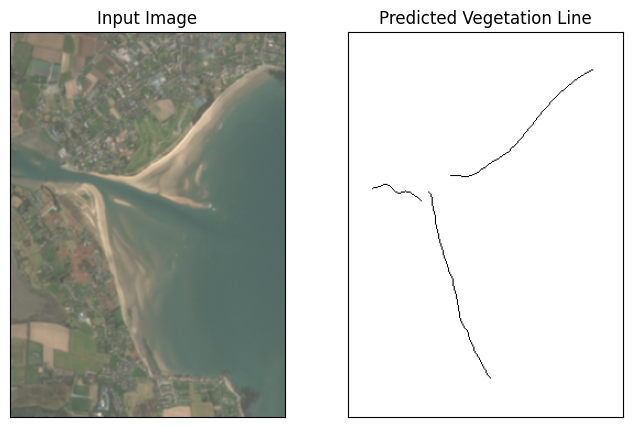

In [7]:
fig, ax = plt.subplots(1,2, figsize=(8,5))

rgb_image = utils.get_rgb(image,r=0,g=1,b=2,contrast=0.4)

ax[0].imshow(rgb_image)
ax[0].set_title('Input Image')

ax[1].imshow(1-pred, cmap='gray')
ax[1].set_title('Predicted Vegetation Line')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])